# Conditional-method comparison

Analyses a `compare_conditional_methods` experiment: all runs are `lsharp` with
don't-care + reference language, and the only swept dimension is
`conditional_method`. Plotting/summary logic is reused from
`tover.analysis.breakdown`.

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("../")

In [2]:
from tover.analysis.load_data import load_experiment_data, add_symbol_color, clean_data
from tover.analysis.breakdown import (
    plot_runtime_breakdown,
    group_summary,
    runtime_pivot,
)
from tover.core.synthesis import ConditionalMethod

PATH = "/home/luko/ToVer/monitor-conformence/out/exp-2026-06-05_09-25-04-compare_conditional_methods"

data = load_experiment_data(PATH)
clean_data(data)
add_symbol_color(data)

# Group by conditional method, keeping the enum's order and dropping empties.
groups = {
    m.value: [d for d in data if d["experiment"].get("conditional_method") == m.value]
    for m in ConditionalMethod
}
groups = {k: v for k, v in groups.items() if v}
{k: len(v) for k, v in groups.items()}

Loaded 82 finished, 2 unfinished, 0 not started (84 total) from /home/luko/ToVer/monitor-conformence/out/exp-2026-06-05_09-25-04-compare_conditional_methods


{'rejection': 12,
 'restart': 12,
 'bisection': 12,
 'bisection_advanced': 12,
 'bisection_pt': 12,
 'bisection_advanced_pt': 12,
 'policy_iteration': 12}

## Success / runtime per method

How many runs each conditional method completes, and the runtime of the ones
that did. The conditional (bisection / pt / policy_iteration) methods may fail
on some benchmarks, so `success %` is the headline metric for "works best".

In [3]:
group_summary(groups).sort_values("success %", ascending=False).reset_index(drop=True)

,group,runs,finished,failed,success %,median (s),total (s),max (s)
0,restart,12,11,1,91.7,10.22,893.6,363.2
1,bisection,12,11,1,91.7,29.41,9786.3,8628.0
2,bisection_advanced,12,11,1,91.7,28.08,8578.4,7408.9
3,bisection_advanced_pt,12,11,1,91.7,19.09,8776.7,7579.3
4,bisection_pt,12,11,1,91.7,29.45,8088.1,6812.9
5,rejection,12,10,2,83.3,24.59,7738.0,4868.4
6,policy_iteration,12,0,12,0.0,NaN,NaN,NaN


## Runtime per benchmark x method

Read across a row to see which method solved a benchmark fastest; `NaN` marks a
run that did not finish (error / timeout / not yet run).

In [4]:
pivot = runtime_pivot(groups)
pivot.style.highlight_min(axis=1, color="#006a25").format("{:.1f}", na_rep="X")

,rejection,restart,bisection,bisection_advanced,bisection_pt,bisection_advanced_pt,policy_iteration
airport airportA-3.nm h=9,4868.4,235.0,8628.0,7408.9,6812.9,7579.3,X
airport airportB-7.nm h=9,2585.5,9.3,752.4,686.1,842.5,808.5,X
evade evade-monitoring.nm h=7,13.7,13.1,15.3,14.0,13.7,15.1,X
evade evade-monitoring.nm h=9,129.1,137.0,144.0,167.2,150.8,153.6,X
hidden_incentive hidden-incentive.nm h=8,35.5,10.2,29.4,28.1,29.4,29.0,X
icy-driving icy-driving.pm h=10,1.4,1.0,0.2,0.2,0.2,0.2,X
icy-driving icy-driving.pm h=25,inf,inf,168.2,159.2,183.3,154.7,X
refuel refuel.nm h=10,5.1,6.1,6.5,6.8,7.0,7.2,X
refuel refuelB.nm h=10,8.5,363.2,10.2,6.2,8.4,7.4,X
snakes_ladders mc_u_nxn.pm h=10,1.5,0.9,2.4,1.8,2.1,2.7,X


## Inspect a specific run

Once a cell of interest is spotted above, `find_runs` returns the matching runs
with their `json` / `log` paths, using the same coordinates as the pivot:
`group` is the exact column label and `benchmark` is a substring of the row
label. `links=True` renders the paths as clickable file links.

In [5]:
from tover.analysis.breakdown import find_runs

# group=<column>, benchmark=<substring of a pivot row>; drop either to widen.
find_runs(groups, group="restart", benchmark="snakes_ladders mc_u_nxn.pm h=12", links=False)


,group,benchmark,runtime,finished,error,json,log
0,restart,snakes_ladders mc_u_nxn.pm h=12,0.8,True,None,/home/luko/ToVer/monitor-conformence/out/exp-2...,/home/luko/ToVer/monitor-conformence/out/exp-2...


## Runtime breakdown

Clusters = benchmark, bars = conditional method (compared side by side). Each
stacked bar is the phase composition; the dot above it is total runtime on the
right-hand log axis.

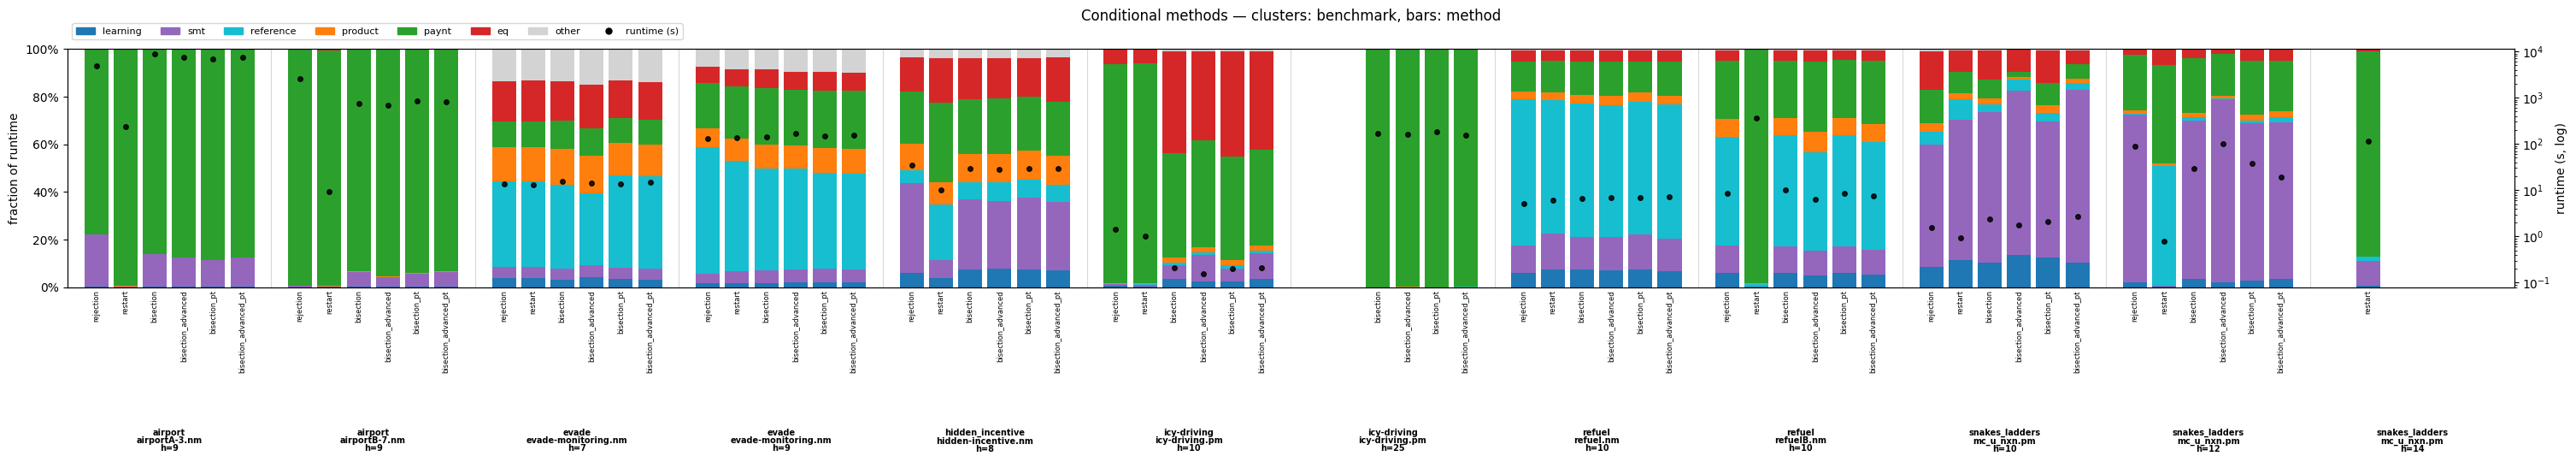

In [6]:
plot_runtime_breakdown(
    groups,
    relative=True,
    title="Conditional methods — clusters: benchmark, bars: method",
)

## Pairwise runtime scatter (optional)

Reuses `compare_runtimes` to put one method against another on a log-log plot;
pick any two method keys from `groups`.

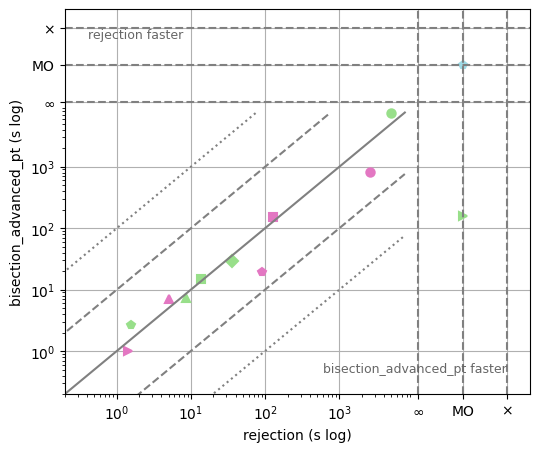

In [7]:
from tover.analysis.plots import compare_runtimes

m1, m2 = "rejection", "bisection_advanced_pt"
compare_runtimes(
    groups[m1],
    groups[m2],
    label1=m1,
    label2=m2,
    figsize=(6, 5),
    plot_kwargs={"markersize": 6, "markeredgewidth": 1.5},
)